# 🛒 EPOCH 5th Pilot Task Week4 (박정민)
> **주제: BMI 지수와 실제 비만 등급의 괴리 분석**
>> 부제: BMI 지표의 한계 극복을 위한 생활 습관 기반 비만 위험도 재정의


## Step1. 데이터 확인과 EDA + 전처리

**컬럼 정보 (한글)**  
- 수치형
> - Age : 나이
> - Height: 키
> - Weight: 몸무게
> - FCVC : 채소 섭취 빈도
> - NCP : 하루 섭취 끼니수
> - CH2O: 하루 섭취 물 양
> - FAF: 신체 활동 빈도
> - TUE : 전자기기 사용 빈도(휴대폰, 비디오게임, TV, 컴퓨터 등)

- 범주형
> - Gender: 성별
> - family_history_with_overweight: 과체중 가족력
> - FAVC : 고칼로리 음식 섭취 빈도
> - CAEC : 식사 사이 군것질 빈도
> - SMOKE : 흡연 여부
> - SCC: 섭취 칼로리 모니터링 여부
> - CALC : 알콜 섭취 빈도
> - MTRANS : 주로 사용하는 교통수단
> - NObeyesdad : 비만 수준

In [90]:
# 라이브러리 호출하기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [91]:
pd.set_option('display.max_columns', None)

In [92]:
# 데이터셋 호출
df = pd.read_csv('ObesityDataSet_raw.csv')
df_raw = df.copy() # 원본데이터 저장하기

In [93]:
# 변수명 매핑 딕셔너리
rename_dict = {
    'Gender': 'gender',
    'Age': 'age',
    'Height': 'height',
    'Weight': 'weight',
    'family_history_with_overweight': 'family_history',
    'FAVC': 'high_cal_food',
    'FCVC': 'vegetable',
    'NCP': 'meal_count',
    'CAEC': 'snack',
    'SMOKE': 'smoke',
    'CH2O': 'water_intake',
    'SCC': 'cal_monitoring',
    'FAF': 'physical_activity',
    'TUE': 'tech_time',
    'CALC': 'alcohol_intake',
    'MTRANS': 'transport',
    'NObeyesdad': 'obesity_level'
}

df.rename(columns=rename_dict, inplace=True)
print(df.columns)

Index(['age', 'gender', 'height', 'weight', 'alcohol_intake', 'high_cal_food',
       'vegetable', 'meal_count', 'cal_monitoring', 'smoke', 'water_intake',
       'family_history', 'physical_activity', 'tech_time', 'snack',
       'transport', 'obesity_level'],
      dtype='object')


In [94]:
# 수치형, 범주형 변수들 저장
num_cols = ['age', 'height', 'weight', 'vegetable', 'meal_count', 'water_intake', 'physical_activity', 'tech_time']
cat_cols = ['gender', 'family_history', 'high_cal_food', 'snack',
            'smoke', 'cal_monitoring', 'alcohol_intake', 'transport', 'obesity_level']

In [95]:
df.head()  # 앞 5행 출력하기

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,transport,obesity_level
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [96]:
df.info()  # 데이터 정보 확인하기

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2111 non-null   float64
 1   gender             2111 non-null   object 
 2   height             2111 non-null   float64
 3   weight             2111 non-null   float64
 4   alcohol_intake     2111 non-null   object 
 5   high_cal_food      2111 non-null   object 
 6   vegetable          2111 non-null   float64
 7   meal_count         2111 non-null   float64
 8   cal_monitoring     2111 non-null   object 
 9   smoke              2111 non-null   object 
 10  water_intake       2111 non-null   float64
 11  family_history     2111 non-null   object 
 12  physical_activity  2111 non-null   float64
 13  tech_time          2111 non-null   float64
 14  snack              2111 non-null   object 
 15  transport          2111 non-null   object 
 16  obesity_level      2111 

In [97]:
df.shape  # 데이터 행, 열 확인하기

(2111, 17)

In [98]:
df.nunique()  # 데이터의 고유값 확인하기

,0
age,1402
gender,2
height,1574
weight,1525
alcohol_intake,4
high_cal_food,2
vegetable,810
meal_count,635
cal_monitoring,2
smoke,2


In [99]:
df.describe(include = 'all')  # 모든 피쳐의 요약통계량 확인하기

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,transport,obesity_level
count,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1068,NaN,NaN,1401,1866,NaN,NaN,2015,2067,NaN,1726,NaN,NaN,1765,1580,351
mean,24.312600,NaN,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,6.345968,NaN,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,14.000000,NaN,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,19.947192,NaN,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,22.777890,NaN,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,26.000000,NaN,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


In [100]:
df.isnull().sum()  # 결측치 확인

,0
age,0
gender,0
height,0
weight,0
alcohol_intake,0
high_cal_food,0
vegetable,0
meal_count,0
cal_monitoring,0
smoke,0


In [101]:
df.duplicated().sum()  # 중복 데이터 확인

np.int64(24)

In [102]:
df.drop_duplicates(inplace=True)  # 중복데이터 제거
df.shape  # 중복데이터 제거가 되어었는지 확인

(2087, 17)

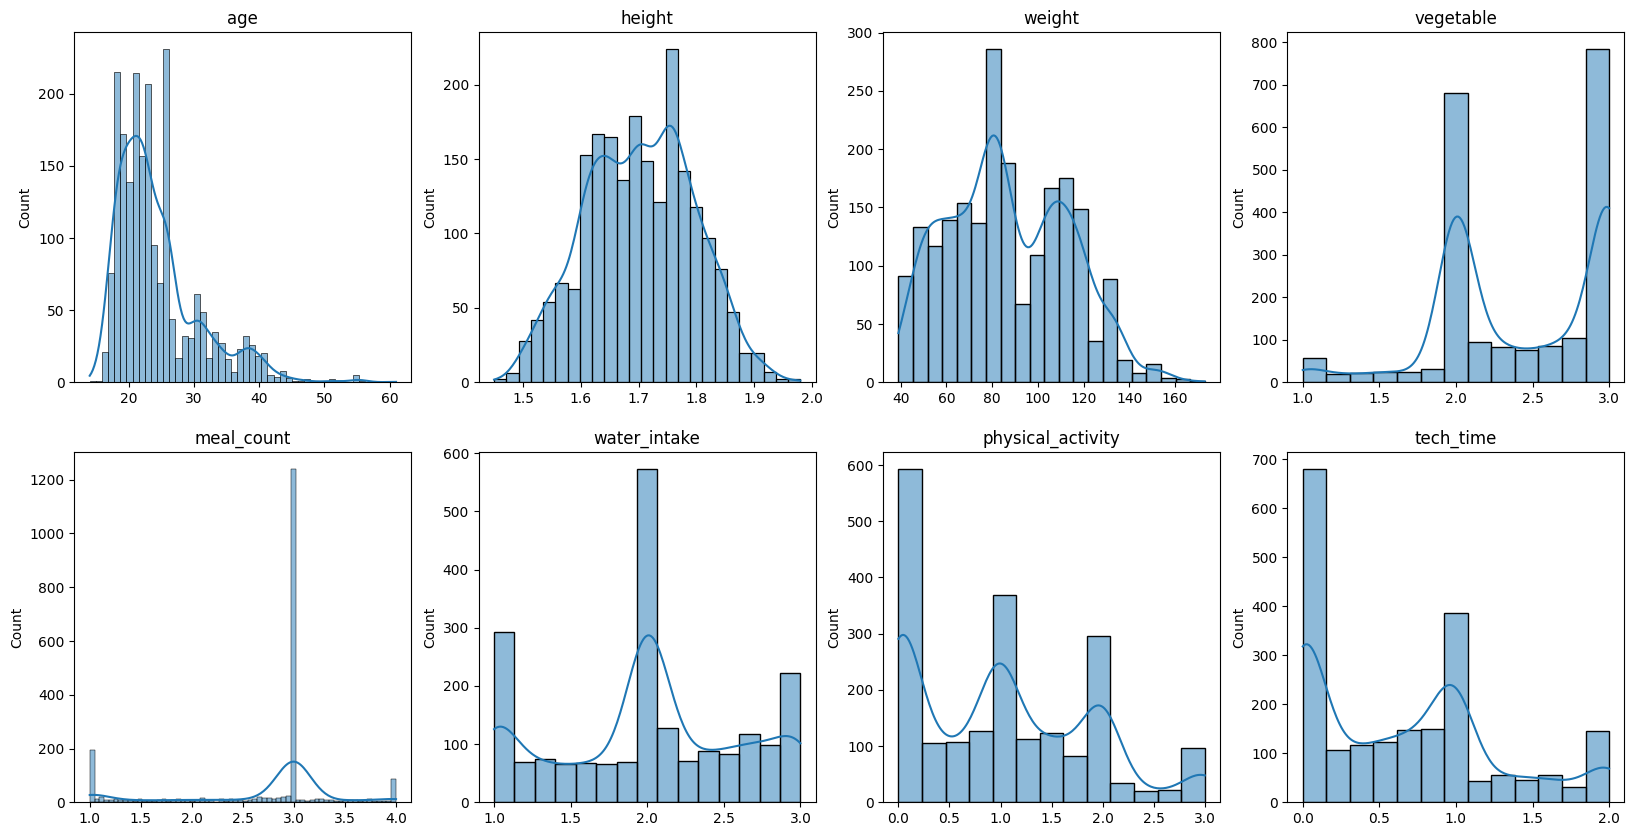

In [103]:
# 수치형 변수 (8개)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # subgraph 2행 4열

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i//4, i%4])  # 각 변수에 대한 히스토그램
    axes[i//4, i%4].set_title(col)
    axes[i//4, i%4].set_xlabel('')
plt.show()

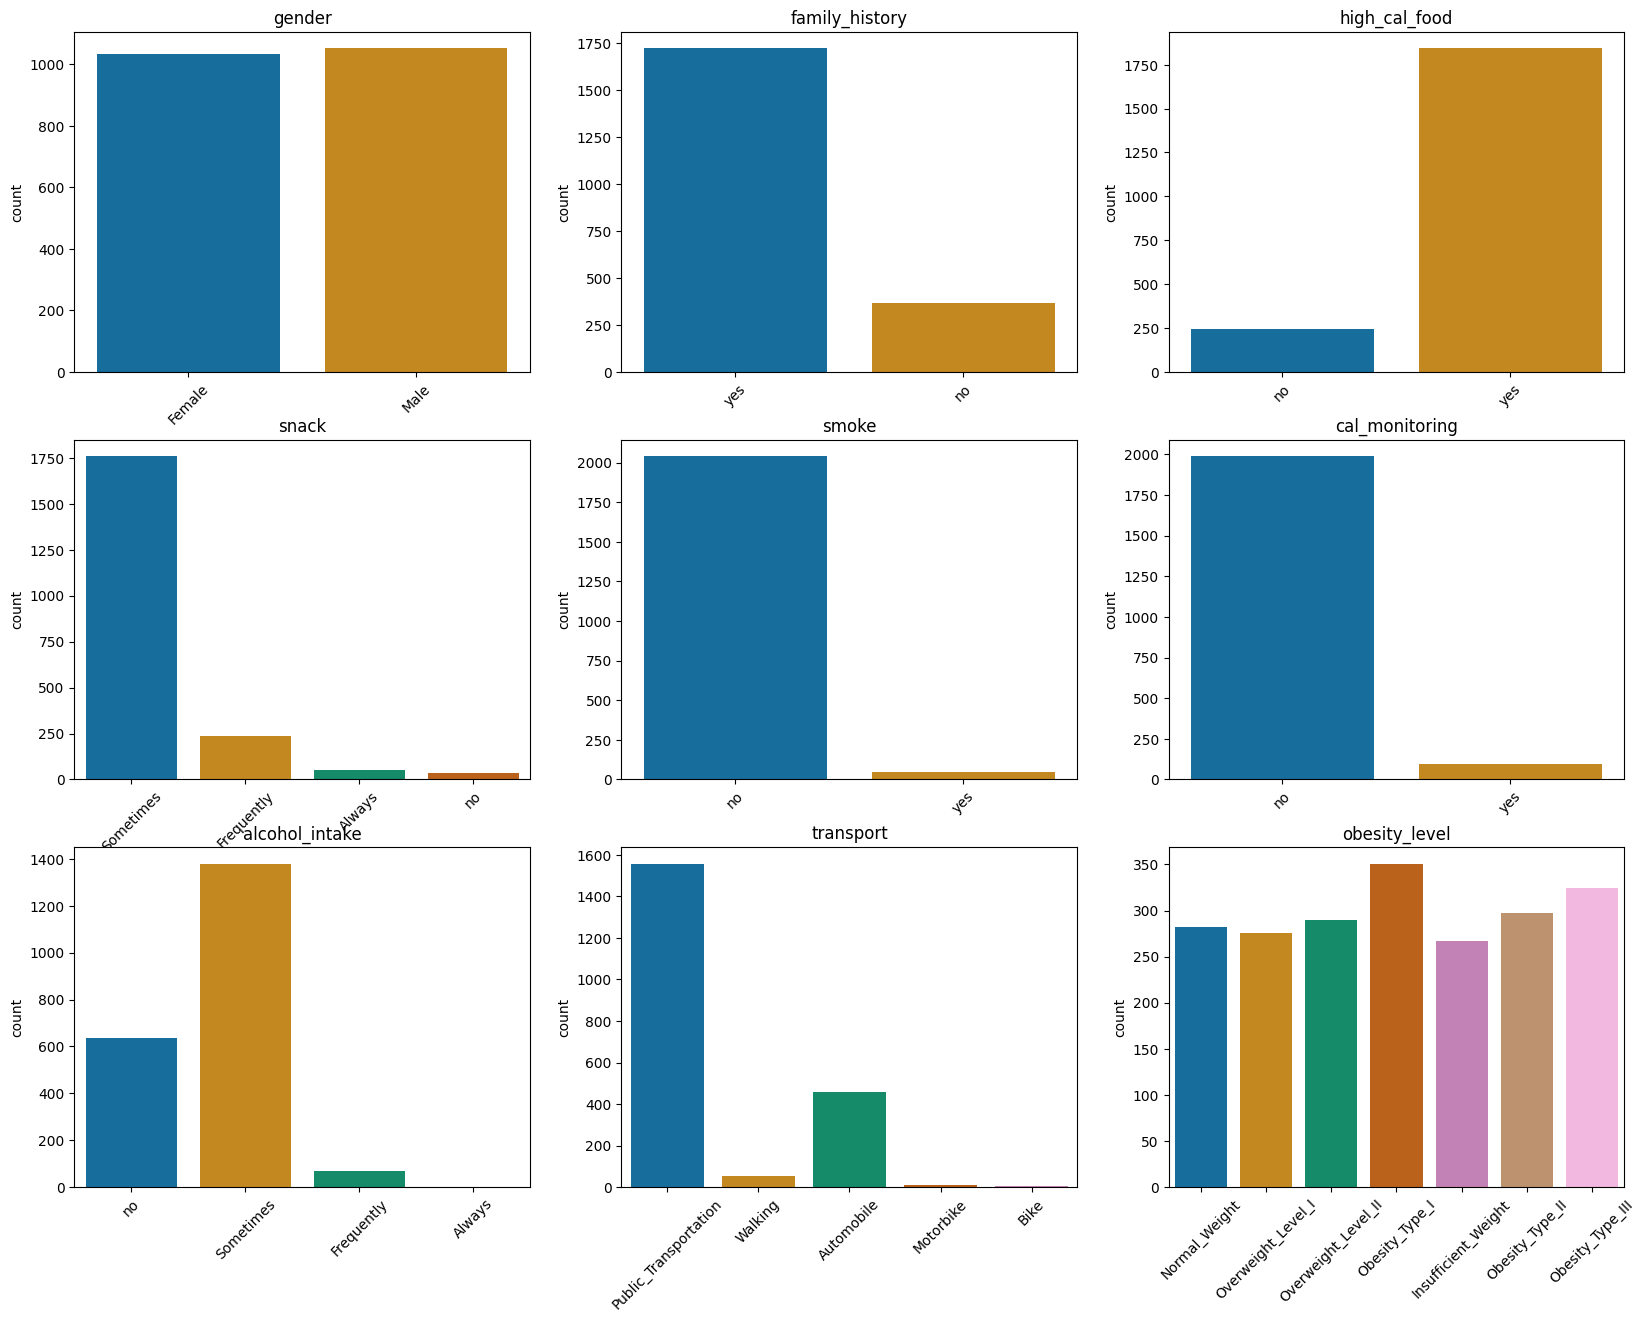

In [104]:
# 범주형 변수 (9개)
fig, axes = plt.subplots(3, 3, figsize=(20, 15))  # subgraph 3행 3열

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i//3, i%3], palette='colorblind')  # 각 변수에 대한 countplot
    axes[i//3, i%3].set_title(col)
    axes[i//3, i%3].tick_params(axis='x', rotation=45)
    axes[i//3, i%3].set_xlabel('')
plt.show()

In [105]:
# 범주형 변수의 고유값 비율 확인
for col in cat_cols:
    print("===[", col, "]===")
    count = df[col].value_counts()
    ratio = df[col].value_counts(normalize=True) * 100

    report = pd.DataFrame({'Count': count, 'Percentage (%)': ratio.round(2)})
    print(report)
    print("\n")

===[ gender ]===
        Count  Percentage (%)
gender                       
Male     1052           50.41
Female   1035           49.59


===[ family_history ]===
                Count  Percentage (%)
family_history                       
yes              1722           82.51
no                365           17.49


===[ high_cal_food ]===
               Count  Percentage (%)
high_cal_food                       
yes             1844           88.36
no               243           11.64


===[ snack ]===
            Count  Percentage (%)
snack                            
Sometimes    1761           84.38
Frequently    236           11.31
Always         53            2.54
no             37            1.77


===[ smoke ]===
       Count  Percentage (%)
smoke                       
no      2043           97.89
yes       44            2.11


===[ cal_monitoring ]===
                Count  Percentage (%)
cal_monitoring                       
no               1991            95.4
yes          

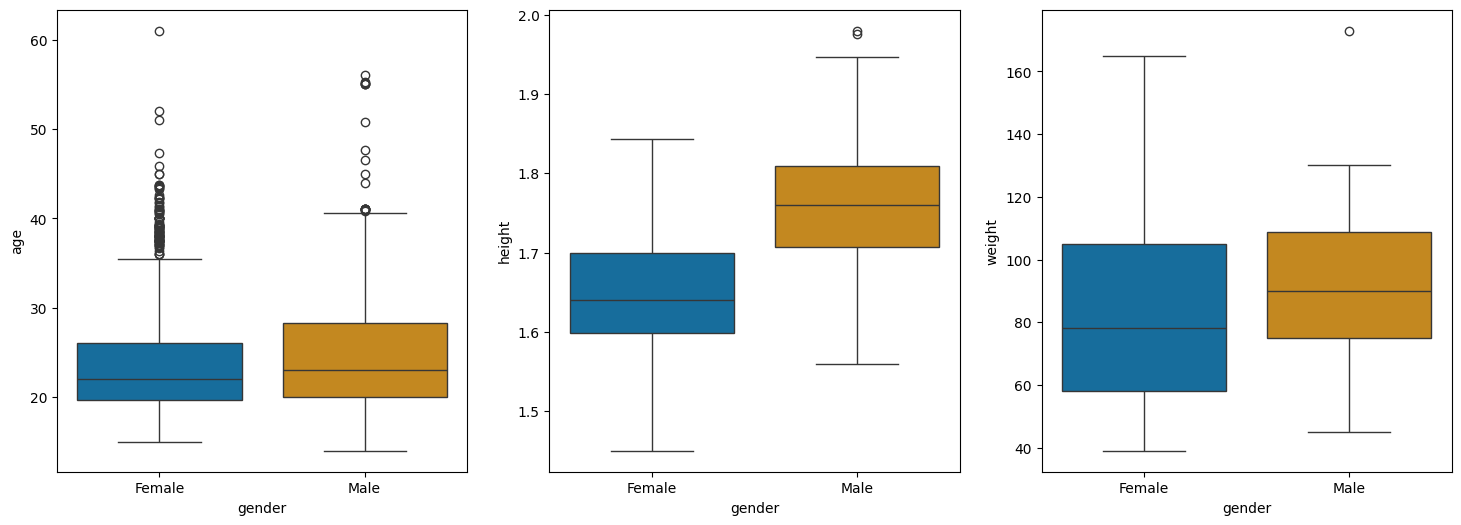

In [106]:
# 나이, 키, 몸무게만 따로 확인
features = ['age', 'height', 'weight']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # subgraph 1행 3열

for i, col in enumerate(features):
    sns.boxplot(x='gender', y=col, data=df, ax=axes[i], palette='colorblind')  # 성별에 따른 각 변수 boxplot
    axes[i].set_xlabel('gender')
    axes[i].set_ylabel(col)
plt.show()

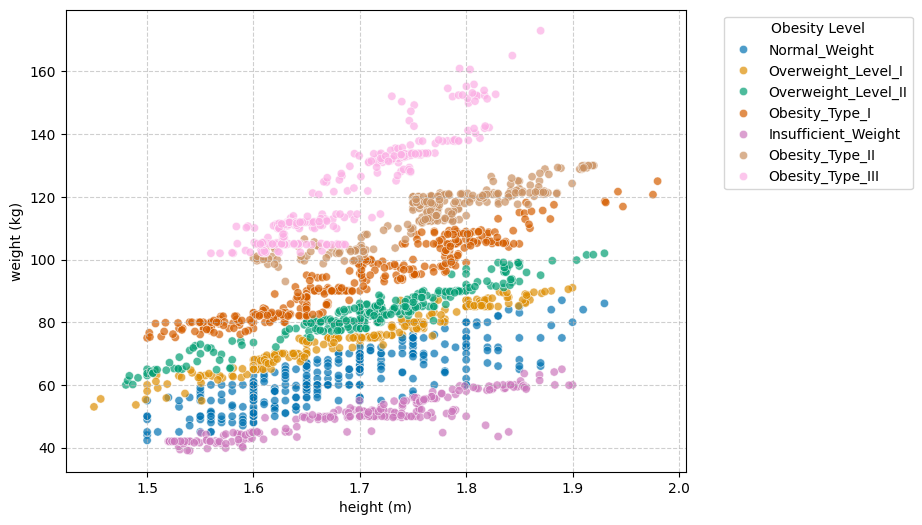

In [107]:
# 키와 몸무게의 산점도 그림
plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x='height', y='weight', hue='obesity_level',
                palette='colorblind', alpha=0.7)

plt.xlabel('height (m)')
plt.ylabel('weight (kg)')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

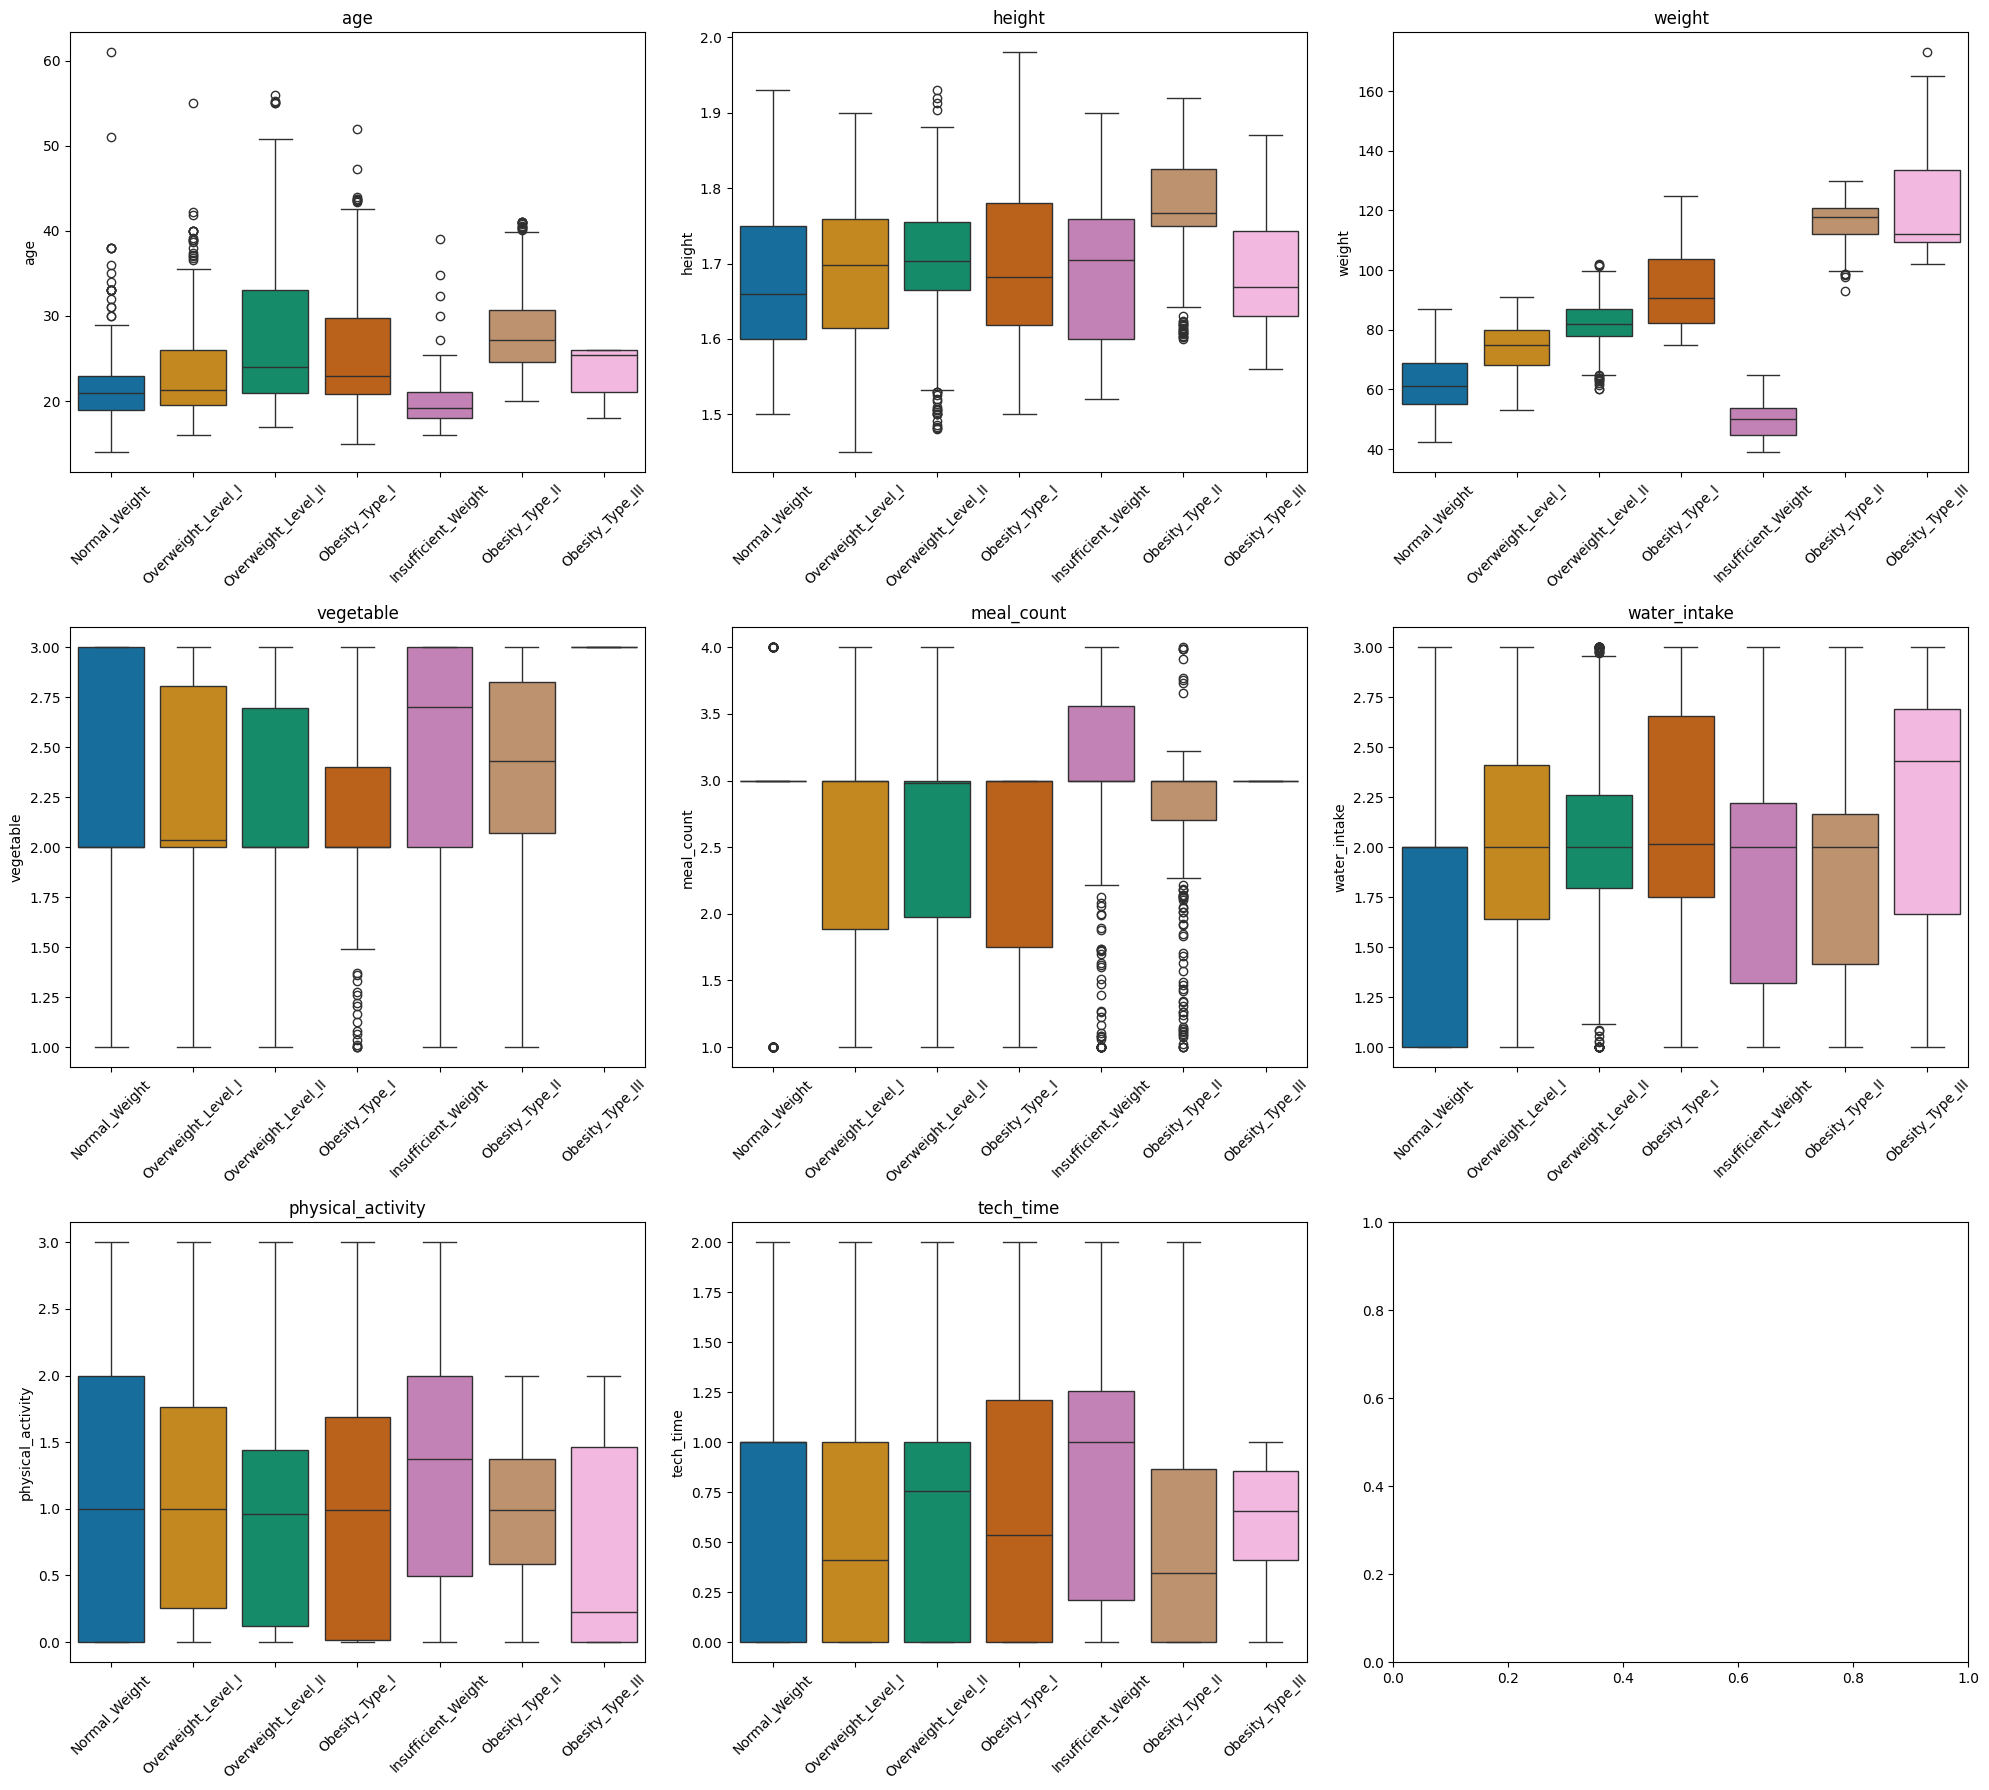

In [108]:
# 수치형 변수(num_col)
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='obesity_level', y=col, ax=axes[i],
                hue='obesity_level', palette='colorblind', legend=False)   # 비만수준에 따른 수치형 변수들 boxplot
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

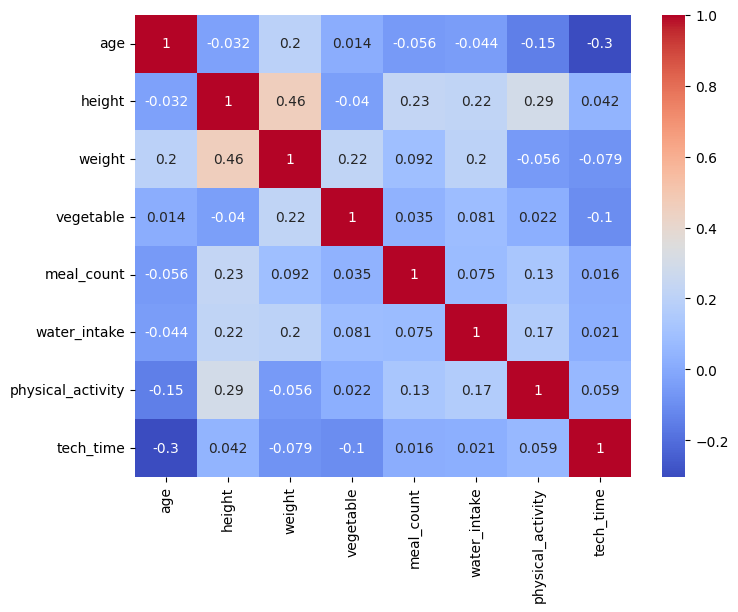

In [109]:
# 상관관계 히트맵 확인
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.yticks(rotation=0)
plt.show()

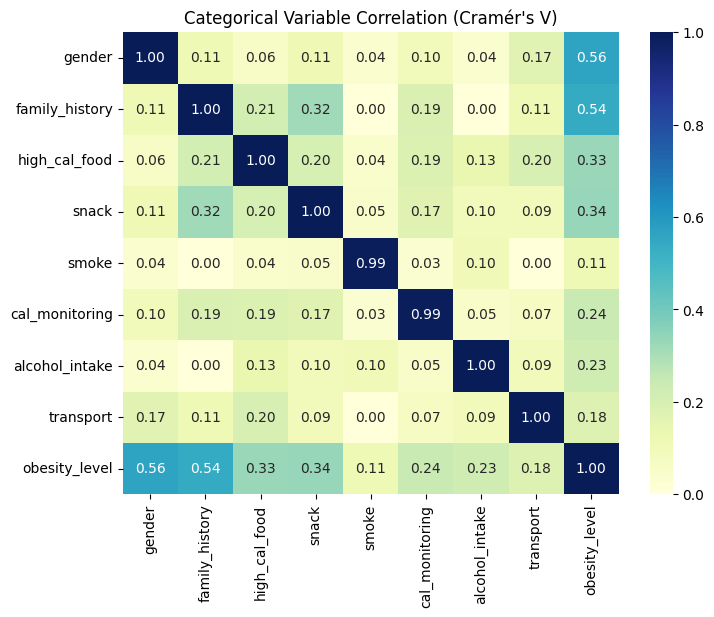

In [110]:
# 범주형 크래머 V 계수를 활용한 상관관계 확인 (카이제곱)
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

rows = []
for x in cat_cols:
    col = []
    for y in cat_cols:
        col.append(cramers_v(df[x], df[y]))
    rows.append(col)

v_matrix = pd.DataFrame(rows, columns=cat_cols, index=cat_cols)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(v_matrix, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Categorical Variable Correlation (Cramér's V)")
plt.show()

In [111]:
df.columns

Index(['age', 'gender', 'height', 'weight', 'alcohol_intake', 'high_cal_food',
       'vegetable', 'meal_count', 'cal_monitoring', 'smoke', 'water_intake',
       'family_history', 'physical_activity', 'tech_time', 'snack',
       'transport', 'obesity_level'],
      dtype='object')

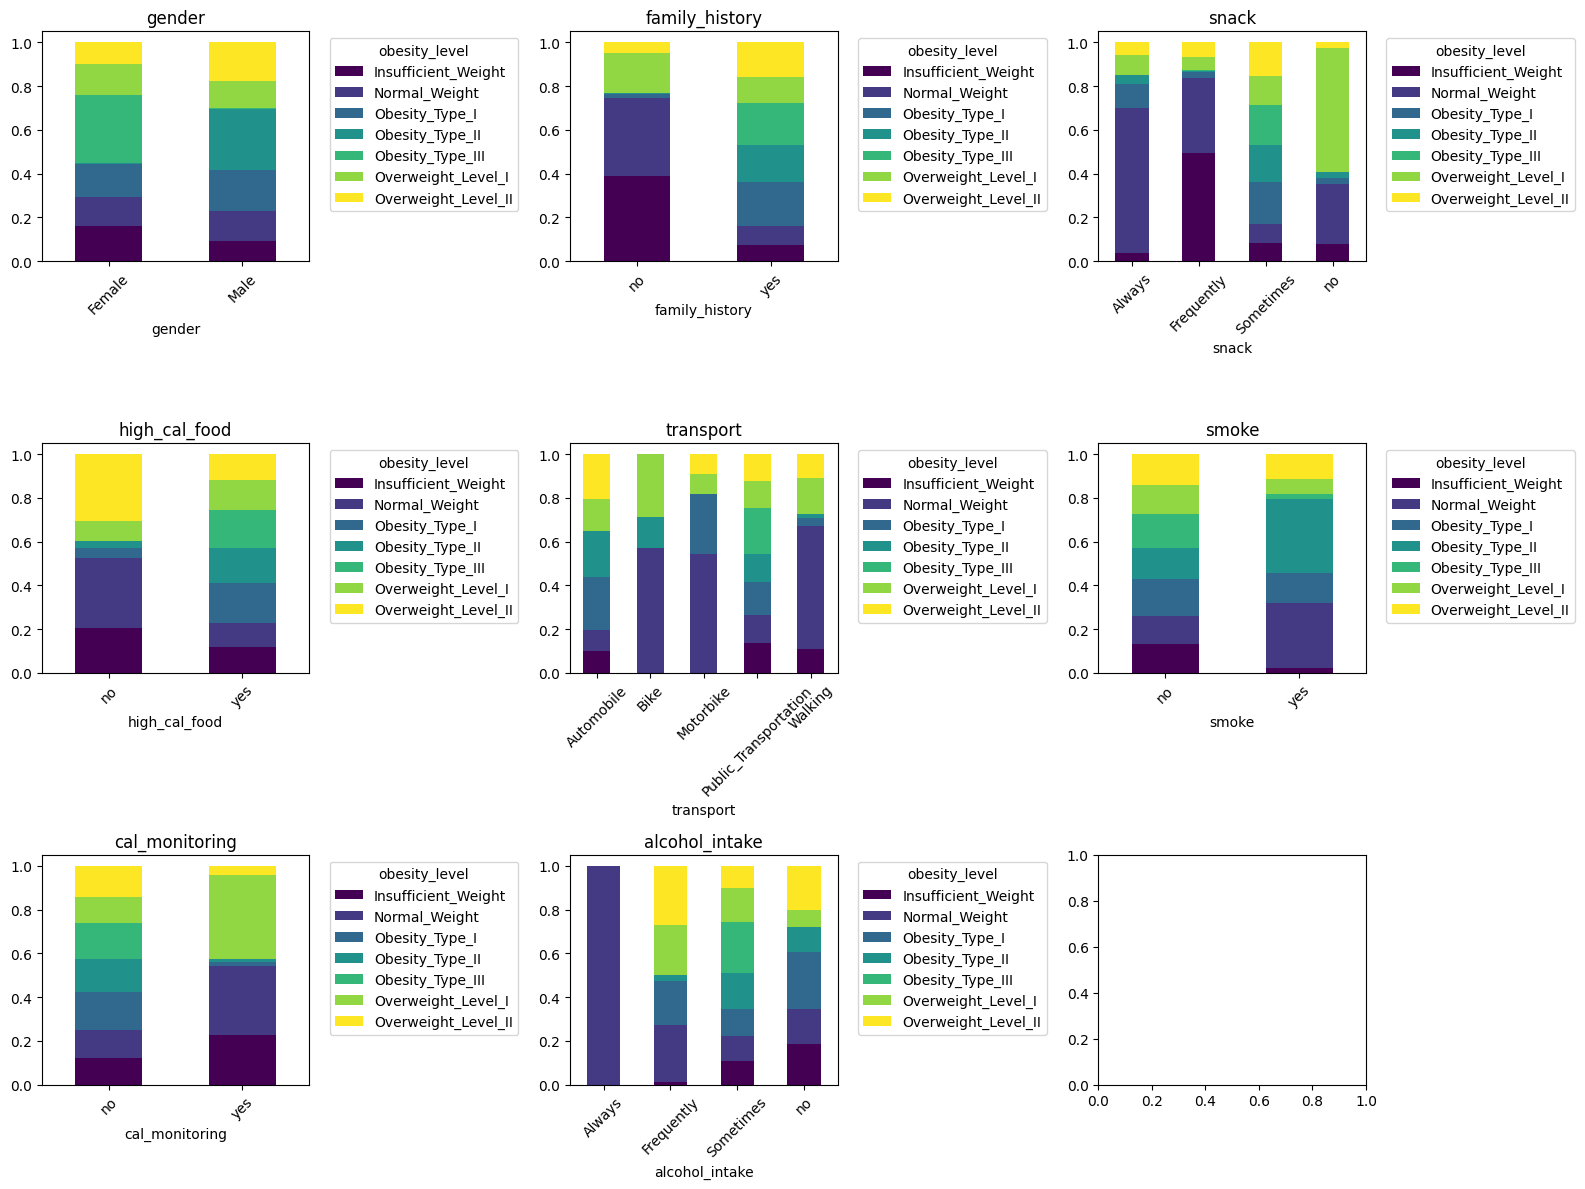

In [112]:
# 정규화 비율 누적 막대 그래프
target_features = ['gender', 'family_history', 'snack', 'high_cal_food', 'transport', 'smoke', 'cal_monitoring', 'alcohol_intake']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(target_features):
    ct = pd.crosstab(df[col], df['obesity_level'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(col)
    axes[i].legend(title='obesity_level', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## Step2. 인코딩 및 피쳐 엔지니어링

In [113]:
from sklearn.preprocessing import LabelEncoder

df_final = df.copy()

# 이진 및 순서형 수동 매핑
binary_map = {'yes': 1, 'no': 0}
gender_map = {'Male': 1, 'Female': 0}

df_final['gender'] = df_final['gender'].map(gender_map)
for col in ['high_cal_food', 'smoke', 'cal_monitoring', 'family_history']:
    df_final[col] = df_final[col].map(binary_map)

# 명목형 변수 원-핫 인코딩 (transport)
df_final = pd.get_dummies(df_final, columns=['transport'], drop_first=True)

# 타겟 변수 인코딩 (obesity_level)
obesity_map = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1,
    'Overweight_Level_I': 2, 'Overweight_Level_II': 3,
    'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}
df_final['obesity_target'] = df_final['obesity_level'].map(obesity_map)
df_final.head()

,age,gender,height,weight,alcohol_intake,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,snack,obesity_level,transport_Bike,transport_Motorbike,transport_Public_Transportation,transport_Walking,obesity_target
0,21.0,0,1.62,64.0,no,0,2.0,3.0,0,0,2.0,1,0.0,1.0,Sometimes,Normal_Weight,False,False,True,False,1
1,21.0,0,1.52,56.0,Sometimes,0,3.0,3.0,1,1,3.0,1,3.0,0.0,Sometimes,Normal_Weight,False,False,True,False,1
2,23.0,1,1.80,77.0,Frequently,0,2.0,3.0,0,0,2.0,1,2.0,1.0,Sometimes,Normal_Weight,False,False,True,False,1
3,27.0,1,1.80,87.0,Frequently,0,3.0,3.0,0,0,2.0,0,2.0,0.0,Sometimes,Overweight_Level_I,False,False,False,True,2
4,22.0,1,1.78,89.8,Sometimes,0,2.0,1.0,0,0,2.0,0,0.0,0.0,Sometimes,Overweight_Level_II,False,False,True,False,3


In [114]:
# BMI 수치 계산 [공식: BMI = 몸무게(kg) / 키(m)^2]
df_final['bmi_score'] = df_final['weight'] / (df_final['height']**2)

# WHO에서 정한 4개의 기준보다 현재 데이터셋에 맞게 7개로 분할
def get_bmi_target_7(bmi):
    if bmi < 18.5: return 0    # Insufficient
    elif bmi < 25: return 1    # Normal
    elif bmi < 27.5: return 2  # Overweight I
    elif bmi < 30: return 3    # Overweight II
    elif bmi < 35: return 4    # Obesity I
    elif bmi < 40: return 5    # Obesity II
    else: return 6             # Obesity III

df_final['bmi_predicted_target'] = df_final['bmi_score'].apply(get_bmi_target_7)

In [115]:
# 나이대 변수 생성
df_final['age_group'] = pd.cut(df_final['age'], bins=[0, 20, 30, 40, 50, 60], labels=['10s', '20s', '30s', '40s', '50s'])

# 나이대별 비만 등급 비중 계산
age_obesity_pct = pd.crosstab(df_final['age_group'], df_final['obesity_level'], normalize='index') * 100

In [116]:
from sklearn.preprocessing import MinMaxScaler

# 숫자 매핑 (인코딩)
snack_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
alc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

df_final['snack_num'] = df_final['snack'].map(snack_map)
df_final['alc_num'] = df_final['alcohol_intake'].map(alc_map)

# 스케일링할 컬럼 선택
features_to_scale = ['high_cal_food', 'snack_num', 'alc_num',
                     'vegetable', 'physical_activity', 'water_intake']

# MinMaxScaler 적용 (새 파생변수를 위해 스케일을 맞춰주기)
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_final[features_to_scale])

# 결과를 데이터프레임으로 다시 만들기 (가독성을 위해)
scaled_df = pd.DataFrame(scaled_values, columns=[f's_{col}' for col in features_to_scale])

# 종합 습관 위험 점수 계산
# 안 좋은 습관(s_high_cal, s_snack, s_alc) - 좋은 습관(s_veg, s_exercise, s_water)
df_final['habit_risk_score'] = (scaled_df['s_high_cal_food'] + scaled_df['s_snack_num'] + scaled_df['s_alc_num']) - \
                         (scaled_df['s_vegetable'] + scaled_df['s_physical_activity'] + scaled_df['s_water_intake'])

# 나이 가중치 적용 (2번에서의 추가적인 파생변수)
df_final['age_buffer_index'] = df_final['habit_risk_score'] / (df_final['age'] + 0.001)
df_final[['habit_risk_score', 'age_buffer_index']].head()

,habit_risk_score,age_buffer_index
0,-0.666667,-0.031745
1,-2.333333,-0.111106
2,-0.666667,-0.028984
3,-1.166667,-0.043208
4,-0.333333,-0.015151


In [118]:
drop_cols = ['snack', 'alcohol_intake', 'obesity_level', 'age_group']
df_final = df_final.drop(columns=drop_cols)

In [120]:
df_final.describe(include='all')

,age,gender,height,weight,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,transport_Bike,transport_Motorbike,transport_Public_Transportation,transport_Walking,obesity_target,bmi_score,bmi_predicted_target,snack_num,alc_num,habit_risk_score,age_buffer_index
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087,2087,2087,2087,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2063.000000,2063.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2080,2076,1558,2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,24.353090,0.504073,1.702674,86.858730,0.883565,2.421466,2.701179,0.045999,0.021083,2.004749,0.825108,1.012812,0.663035,NaN,NaN,NaN,NaN,3.132247,29.765758,3.067082,1.146143,0.729756,-0.039627,-0.001439
std,6.368801,0.500103,0.093186,26.190847,0.320823,0.534737,0.764614,0.209533,0.143695,0.608284,0.379966,0.853475,0.608153,NaN,NaN,NaN,NaN,1.985747,8.024934,1.960371,0.459494,0.517008,0.678787,0.031097
min,14.000000,0.000000,1.450000,39.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,12.998685,0.000000,0.000000,0.000000,-2.666667,-0.140343
25%,19.915937,0.000000,1.630178,66.000000,1.000000,2.000000,2.697467,0.000000,0.000000,1.590922,1.000000,0.124505,0.000000,NaN,NaN,NaN,NaN,1.000000,24.368897,1.000000,1.000000,0.000000,-0.467232,-0.018685
50%,22.847618,1.000000,1.701584,83.101100,1.000000,2.396265,3.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.630866,NaN,NaN,NaN,NaN,3.000000,28.896224,3.000000,1.000000,1.000000,-0.030045,-0.001256
75%,26.000000,1.000000,1.769491,108.015907,1.000000,3.000000,3.000000,0.000000,0.000000,2.466193,1.000000,1.678102,1.000000,NaN,NaN,NaN,NaN,5.000000,36.095538,5.000000,1.000000,1.000000,0.386684,0.016394


In [121]:
# 괴리 여부 확인
# BMI 등급과 실제 진단 등급이 다르면 1, 같으면 0
df_final['is_mismatch'] = (df_final['bmi_predicted_target'] != df_final['obesity_target']).astype(int)

print(f"전체 데이터 중 괴리가 발생하는 샘플 수: {df_final['is_mismatch'].sum()}개")
print(f"괴리율: {df_final['is_mismatch'].mean():.2%}")

전체 데이터 중 괴리가 발생하는 샘플 수: 170개
괴리율: 8.15%


In [123]:
# 괴리가 발생하는 25명의 데이터만 따로 추출
mismatch_df = df_final[df_final['is_mismatch'] == 1]

# 이들의 평균적인 특성 확인
print("--- 괴리 그룹의 평균 특성 ---")
print(mismatch_df[['age', 'height', 'weight', 'bmi_score', 'physical_activity']].mean())

# 이들의 비만 등급 분포 확인
print("\n--- 괴리 그룹의 실제 등급 분포 ---")
print(mismatch_df['obesity_target'].value_counts())

--- 괴리 그룹의 평균 특성 ---
age                  26.887316
height                1.690182
weight               90.109649
bmi_score            31.469399
physical_activity     0.747775
dtype: float64

--- 괴리 그룹의 실제 등급 분포 ---
obesity_target
3    66
6    56
2    18
5    18
4     5
0     4
1     3
Name: count, dtype: int64


In [131]:
df_final.columns

Index(['age', 'gender', 'height', 'weight', 'high_cal_food', 'vegetable',
       'meal_count', 'cal_monitoring', 'smoke', 'water_intake',
       'family_history', 'physical_activity', 'tech_time', 'transport_Bike',
       'transport_Motorbike', 'transport_Public_Transportation',
       'transport_Walking', 'obesity_target', 'bmi_score',
       'bmi_predicted_target', 'snack_num', 'alc_num', 'habit_risk_score',
       'age_buffer_index', 'is_mismatch'],
      dtype='object')

## Step3. 모델링 및 평가

In [124]:
# 랜덤포레스트 모델링
df_enc = df_final.copy()

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df_enc.drop(columns=['obesity_target', 'is_mismatch', 'bmi_predicted_target'])  # 독립 변수
y = df_enc['obesity_target'] # 타겟 변수

# 데이터 분할 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 생성 및 학습
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 성능 확인
y_pred = model.predict(X_test)
print(f"전체 테스트셋 정확도: {accuracy_score(y_test, y_pred):.4f}")

전체 테스트셋 정확도: 0.9904


In [125]:
# 전체 데이터에 대해 모델의 예측값 생성
df_enc['model_predicted_target'] = model.predict(X)

# 괴리 데이터만 추출
mismatch_group = df_enc[df_enc['is_mismatch'] == 1]

# 그 170명 중 모델이 실제 등급을 정확히 맞힌 비율 계산
model_correct_count = (mismatch_group['model_predicted_target'] == mismatch_group['obesity_target']).sum()
model_recovery_rate = model_correct_count / len(mismatch_group)

print(f"--- BMI 오진 그룹(170명)에 대한 모델의 예측 및 복구 성능 ---")
print(f"모델의 정답을 맞힌 수: {model_correct_count}명")
print(f"모델의 정답 복구율: {model_recovery_rate:.2%}")

--- BMI 오진 그룹(170명)에 대한 모델의 예측 및 복구 성능 ---
모델의 정답을 맞힌 수: 169명
모델의 정답 복구율: 99.41%


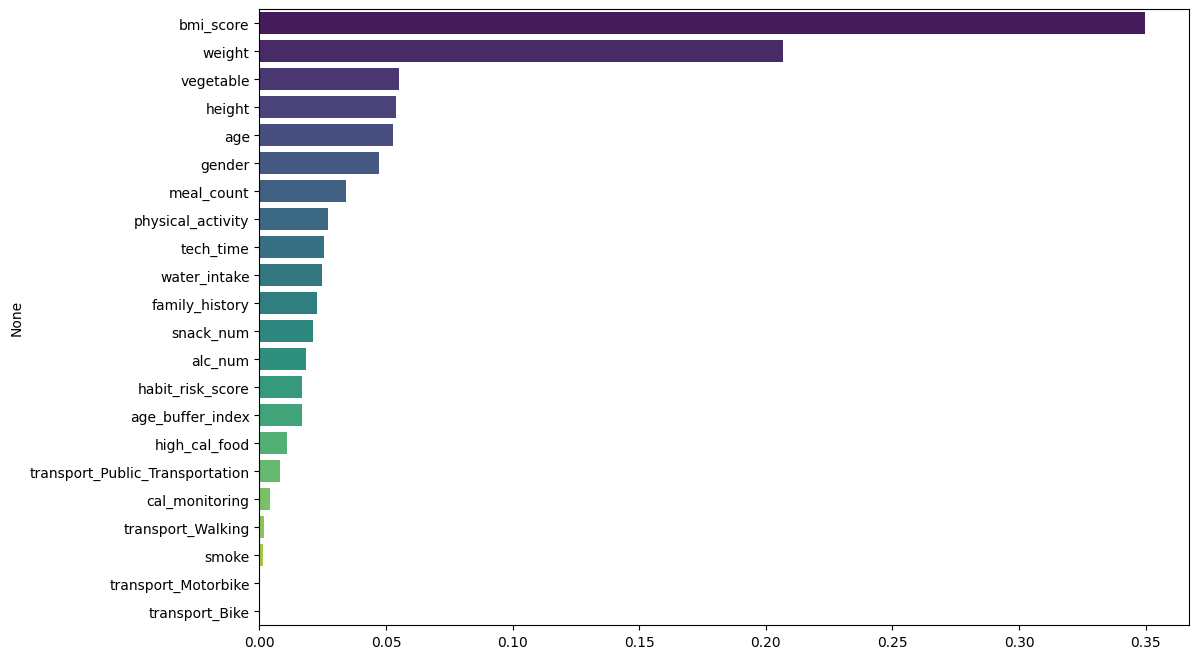

In [126]:
# 변수 중요도 추출
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.show()

In [132]:
# 몸무게, 키, BMI 점수까지 전부 제거 (오직 습관만 남기기)
df_enc1 = df_enc.copy()

df_match = df_enc1[df_enc1['is_mismatch'] == 0]  # 괴리가 아닌 데이터셋
df_mismatch = df_enc1[df_enc1['is_mismatch'] == 1]  # 괴리인 데이터셋

# 타겟 변수와 BMI관련 피쳐 제거
drop_cols_hard = ['obesity_target', 'is_mismatch', 'bmi_predicted_target',
                  'weight', 'height', 'bmi_score', 'model_predicted_target']

# X와 Y 분리
X_train_hard = df_match.drop(columns=drop_cols_hard)
y_train_hard = df_match['obesity_target']

X_test_hard = df_mismatch.drop(columns=drop_cols_hard)
y_test_hard = df_mismatch['obesity_target']

# 모델 학습
rf_hard = RandomForestClassifier(n_estimators=100, random_state=42)
rf_hard.fit(X_train_hard, y_train_hard)

# 습관만으로 BMI 오진 복구력 테스트
y_pred_hard = rf_hard.predict(X_test_hard)
acc_hard = accuracy_score(y_test_hard, y_pred_hard)

print(f"[습관 전용 모델] BMI 오진 복구율: {acc_hard:.2%}")
print(f"구제 성공: {(y_pred_hard == y_test_hard).sum()}명 / 170명")

[습관 전용 모델] BMI 오진 복구율: 83.53%
구제 성공: 142명 / 170명


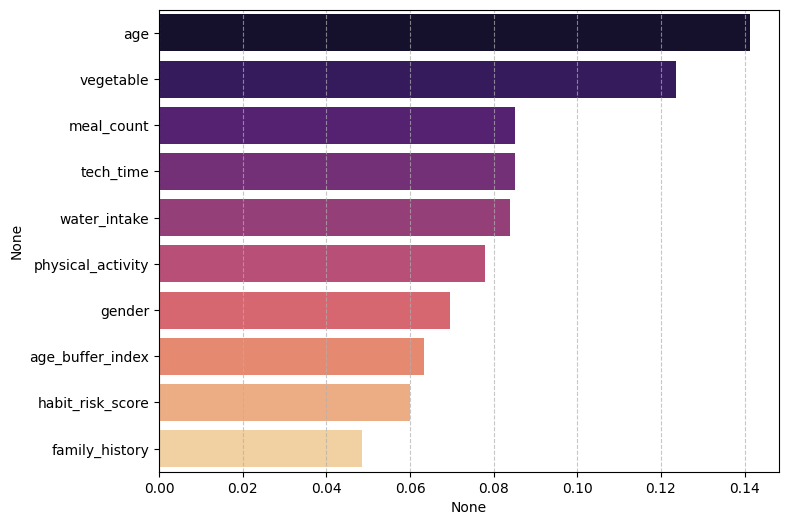

--- Top 10 Feature Importance ---
age                  0.141223
vegetable            0.123637
meal_count           0.085193
tech_time            0.085053
water_intake         0.083858
physical_activity    0.078051
gender               0.069602
age_buffer_index     0.063253
habit_risk_score     0.060090
family_history       0.048420
dtype: float64


In [133]:
# 피쳐 중요도 계산
fi_hard = pd.Series(rf_hard.feature_importances_, index=X_train_hard.columns).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(8, 6))
sns.barplot(x=fi_hard.head(10), y=fi_hard.head(10).index, palette='magma')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("--- Top 10 Feature Importance ---")
print(fi_hard.head(10))

In [134]:
df_mismatch[['obesity_target', 'bmi_predicted_target']]

,obesity_target,bmi_predicted_target
11,3,2
16,3,2
31,3,2
89,3,2
121,3,2
...,...,...
2042,6,5
2044,6,5
2068,6,5
2096,6,5


In [135]:
df_mismatch['obesity_target'].value_counts().sort_index()

,count
obesity_target,
0,4
1,3
2,18
3,66
4,5
5,18
6,56


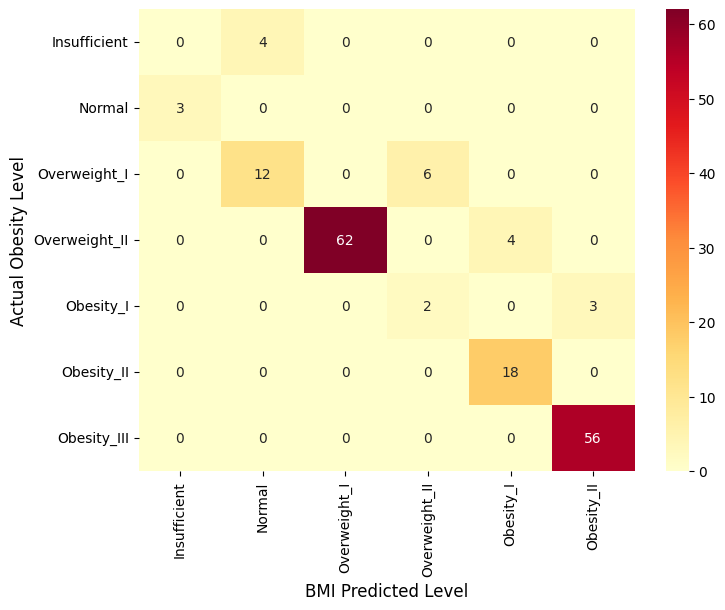

--- 170명 괴리 분석 결과 ---
1. BMI가 실제보다 낮게 평가 (위험 간과): 153명
2. BMI가 실제보다 높게 평가 (과잉 진단): 17명


In [136]:
# 비만 수준 라벨링 (숫자를 문자로)
label_map = {
    0: 'Insufficient', 1: 'Normal', 2: 'Overweight_I',
    3: 'Overweight_II', 4: 'Obesity_I', 5: 'Obesity_II', 6: 'Obesity_III'
}

error_matrix = pd.crosstab(
    df_mismatch['obesity_target'],
    df_mismatch['bmi_predicted_target'],
    dropna=False
)

# 인덱스와 컬럼을 이름으로 변경
error_matrix.index = [label_map[i] for i in error_matrix.index]
error_matrix.columns = [label_map[i] for i in error_matrix.columns]

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(error_matrix, annot=True, fmt='d', cmap='YlOrRd', cbar=True)
plt.xlabel('BMI Predicted Level', fontsize=12)
plt.ylabel('Actual Obesity Level', fontsize=12)
plt.show()

# 방향성 확인
under_est = df_mismatch[df_mismatch['obesity_target'] > df_mismatch['bmi_predicted_target']]
over_est = df_mismatch[df_mismatch['obesity_target'] < df_mismatch['bmi_predicted_target']]

print(f"--- 170명 괴리 분석 결과 ---")
print(f"1. BMI가 실제보다 낮게 평가 (위험 간과): {len(under_est)}명")
print(f"2. BMI가 실제보다 높게 평가 (과잉 진단): {len(over_est)}명")

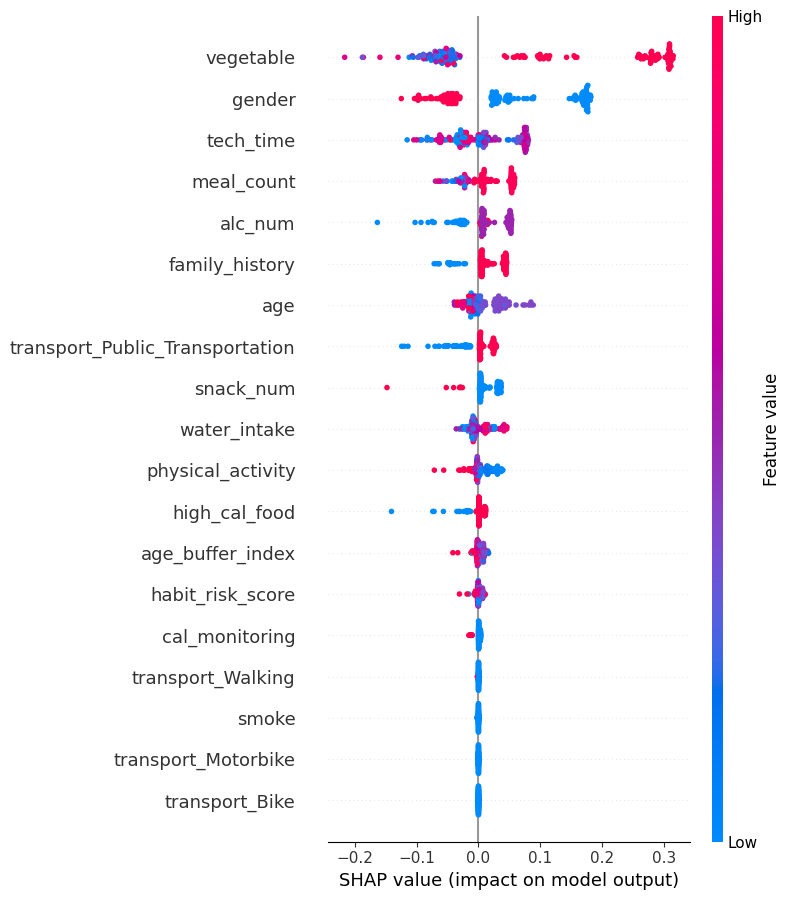

In [137]:
# SHAP 진행
import shap

# SHAP 계산
explainer = shap.TreeExplainer(rf_hard)
shap_values = explainer.shap_values(X_test_hard)

if isinstance(shap_values, list):
    target_shap = shap_values[6]
else:
    target_shap = shap_values[:, :, 6] if len(shap_values.shape) == 3 else shap_values

# 시각화
plt.figure(figsize=(8, 6))
shap.summary_plot(target_shap, X_test_hard)

## Step4. 디벨롭 및 최종 인사이트와 향후 개선사항



[LightGBM 핵심 모델] 전체 테스트셋 정확도: 97.13%


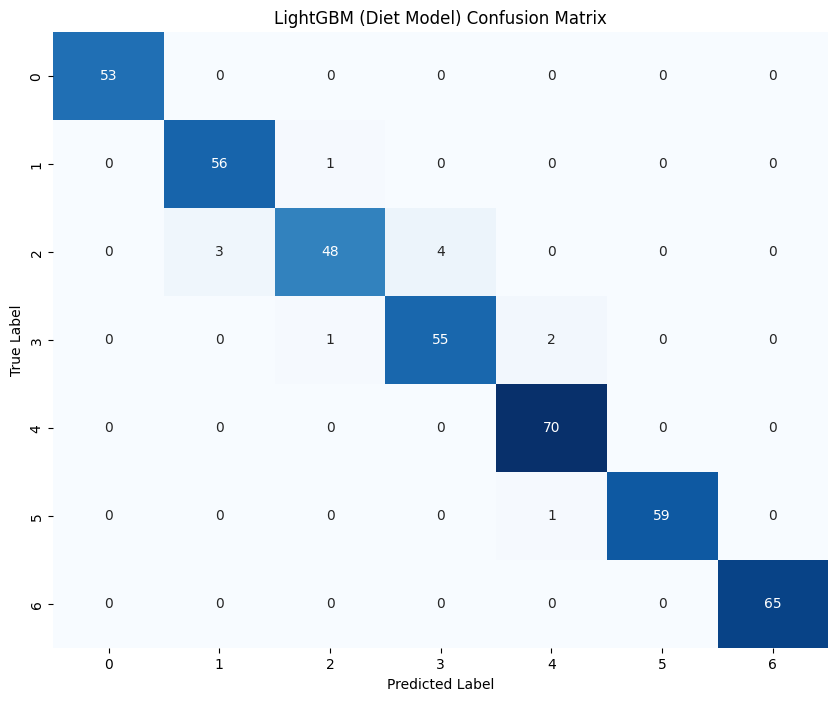

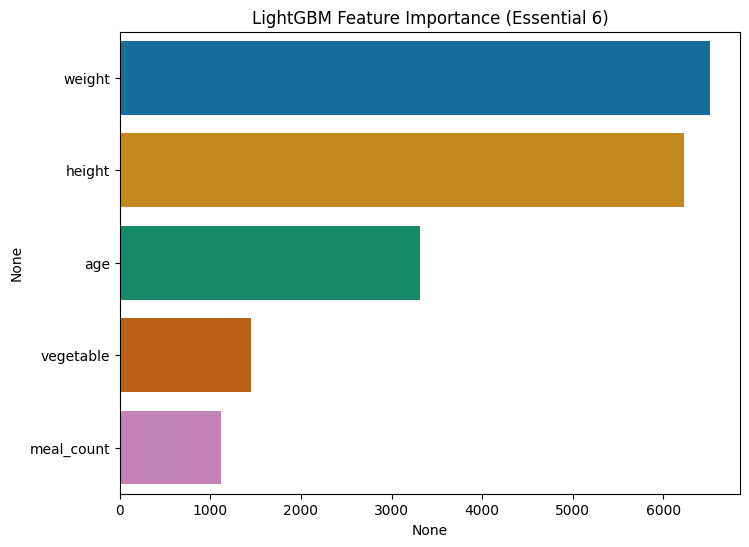

In [146]:
# LightGBM과 baseline의 피쳐 중요도를 통한 피쳐 다이어트
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df_LGBM = df_final.copy()

# 피처 다이어트
# 기존 baseline 모델의 피쳐 중요도를 보며 피쳐 다이어트 진행
# 사용자 경험을 위해 입력값을 최소화하면서 성능을 유지하는 핵심 변수만 선택
essential_cols = ['weight', 'height', 'age',
                  'vegetable', 'meal_count', 'obesity_target']

df_diet = df_LGBM[essential_cols]

# 학습/테스트 데이터 분리
X = df_diet.drop(columns=['obesity_target'])
y = df_diet['obesity_target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# LightGBM 모델 생성 및 학습
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,      # 트리 개수 (너무 많으면 모델이 무거워짐)
    learning_rate=0.1,     # 학습률
    num_leaves=31,         # 트리 복잡도 제어
    random_state=42,
    n_jobs=-1,
    objective='multiclass', # 다중 클래스 분류
    metric='multi_logloss',
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='multi_logloss'
)

# 모델 평가
y_pred = lgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n[LightGBM 핵심 모델] 전체 테스트셋 정확도: {accuracy:.2%}")

# 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('LightGBM (Diet Model) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 변수 중요도(Feature Importance) 확인
fi = pd.Series(lgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=fi, y=fi.index, palette='colorblind')
plt.title('LightGBM Feature Importance (Essential 6)')
plt.show()

In [147]:
# 모델이 학습할 때 사용한 피처 목록 가져오기
trained_features = lgb_model.feature_name_

# 170명의 Mismatch에 해당하는 데이터 준비
X_mismatch_eval = df_final.loc[df_mismatch.index, trained_features]
y_mismatch_eval = df_final.loc[df_mismatch.index, 'obesity_target']

# 모델 예측
y_pred_mismatch = lgb_model.predict(X_mismatch_eval)

# 결과 출력
mismatch_acc = accuracy_score(y_mismatch_eval, y_pred_mismatch)
rescued_count = (y_pred_mismatch == y_mismatch_eval).sum()

print(f"--- [LightGBM {len(trained_features)}개 피처 모델] 검증 결과 ---")
print(f"사각지대 170명 중 정답 복구: {rescued_count}명")
print(f"사각지대 구제율(Recovery Rate): {mismatch_acc:.2%}")

# (선택) 특히 BMI가 낮게 평가했던 153명 중 몇 명을 구했는지 확인
under_idx = df_mismatch[df_mismatch['obesity_target'] > df_mismatch['bmi_predicted_target']].index
X_under = df_final.loc[under_idx, trained_features]
y_under = df_final.loc[under_idx, 'obesity_target']
y_pred_under = lgb_model.predict(X_under)

print(f"\nBMI가 과소평가한 153명 중 정답 복구: {(y_pred_under == y_under).sum()}명")

--- [LightGBM 5개 피처 모델] 검증 결과 ---
사각지대 170명 중 정답 복구: 166명
사각지대 구제율(Recovery Rate): 97.65%

BMI가 과소평가한 153명 중 정답 복구: 151명


## 정리 및 결론
---
- 프로젝트 목표의 변경
  - 기존 목표: BMI 지수와 실제 비만 등급 간의 괴리 분석 및 원인 파악
  - 변경된 목표: BMI 사각지대를 보완할 수 있는 '초경량 비만 판정 모델' 개발 및 서비스 가능성 검증
  - 인사이트
> - 데이터를 확인하니 BMI가 2087개 중 170개정도 판별을 못하고 153명의 위험을 간과하고 있었음.  
> - 단순 BMI수치만으로 비만을 판단하지 말고, 간단한 피쳐들(키, 몸무게, 나이, 채소섭취, 식사량)을 통한 비만확인을 간략하게 웹사이트로 만들어보고자 하였음.
---
- 모델 선택
  - 베이스라인: 랜덤포레스트
    - 피쳐 중요도를 파악할 수 있는 모델인 랜덤포레스트를 베이스라인으로 선택
  - 디벨롭 모델: LightGBM
    - 웹 사이트에서 구동할 수 있는 모델 경량성과 속도를 고려하고, 베포에 최적화가 가능하도록 피쳐가 5개만으로도 안정성있는 모델인 LightGBM 선택
---
- 데이터 해석
  - BMI의 과소평가: BMI와 실제 비만 수준간의 괴리가 존재할 때 BMI는 실제보다 안전하다고 판정함.(실제 수준은 비만 혹은 과체중인데, 이보다 한 수준 낮게 판단) 이는 BMI만 믿고 건강 관리를 소홀히 할 수 있는 '잠재적 위험군'이 존재할 가능성이 농후하다는 판단을 하였음
  - BMI 변수를 제거한 모델링: 해당 모델링을 통해 '나이, 채소섭취량, 하루식사량' 등 BMI가 아닌 변수들도 비만 수준에 생각보다 많은 영향을 미침을 검증할 수 있었음
---
- 최종 결과
  - 간단한 피쳐(키, 몸무게, 나이, 채소, 하루식사량) 5개의 정보만으로 BMI만을 예측을 하지못한 사각지대의 구제율을 95% 이상 달성 가능함을 확인함
  - 효율성의 측면에서 20여 개의 변수를 5개로 줄였음에도 성능 하락이 적기에, 이는 웹사이트에서 간단하게 구현하여 검증할 수 있음을 확인
---
- 결론 및 인사이트
  - BMI만으로도 (즉, 몸무게와 키) 간단하게 비만수준을 파악할 수 있지만, 추가로 나이, 채소섭취, 하루식사량의 피쳐를 추가로 입력하여 간단한 머신러닝을 통해 비만수준을 더욱 정밀하게 판단할 수 있음.
---